# Calidad educativa y desigualdad estructural en Ecuador

### Un análisis exploratorio de datos para el concurso Ecuador Cuantificado 2026

La calidad de la educación —cuánto aprenden realmente los estudiantes, no solo cuántos años
asisten— es uno de los motores del desarrollo y de la movilidad social. En Ecuador ese aprendizaje
no se reparte de forma pareja: depende del nivel socioeconómico de la familia, del territorio y del
tipo de escuela. Este trabajo documenta esas desigualdades con datos verificables y sitúa a Ecuador
frente a los países de mejor desempeño educativo de la región.

**Pregunta de investigación**

> ¿Cómo se transmiten las desigualdades de origen socioeconómico a través de la calidad educativa
> hacia las oportunidades en Ecuador, y qué diferencias estructurales lo separan de los países con
> mejor desempeño educativo?

Para responderla se combinan microdatos nacionales (INEVAL Ser Estudiante, ENEMDU), una evaluación
regional comparable (ERCE 2019 de la UNESCO) e indicadores internacionales (Banco Mundial,
UNESCO-UIS y Our World in Data). El análisis se organiza con un esquema de tres relaciones, usadas
como mapa de qué mirar (sin asumir causalidad):

- **R1. Origen socioeconómico → Calidad.** ¿El nivel socioeconómico de la familia se asocia con el aprendizaje?
- **R2. Educación → Oportunidades.** ¿El nivel educativo se asocia con ingreso y empleo?
- **R3. Recursos → Resultados** (a nivel país). ¿La inversión y el ratio alumno-docente se asocian con el aprendizaje?

El enfoque es **descriptivo y correlacional**: los diseños son transversales y observacionales, así
que se habla de asociaciones y patrones, nunca de causalidad.

El notebook se recorre en cuatro partes: **(1)** exploración y **limpieza** de cada fuente, mostrando
qué contiene, qué significan sus columnas y qué decisiones de limpieza se toman; **(2)** exploración
analítica guiada por las tres relaciones; **(3)** las **visualizaciones** que sustentan la tesis; y
**(4)** la validación metodológica y la síntesis. Cada paso deja a la vista el detalle de los datos
y sus limitaciones.

## 0. Configuración y funciones de apoyo

Librerías y unas pocas funciones reutilizables. Cada fuente tiene su formato; se explica cuando
aparece.

In [1]:
import os, io, re, json, urllib.request
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import pyreadstat

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 150)

DATA = Path("data")
assert DATA.exists(), "Ejecutar desde la raiz del proyecto (donde esta la carpeta data/)."
print("Directorio de trabajo:", os.getcwd())

Directorio de trabajo: /sessions/eager-fervent-dirac/mnt/concurso-visualizador


In [2]:
# Lectura de las evaluaciones INEVAL: separador ; y coma decimal.
# Los codigos 999999, *999999 y celdas vacias representan ausencia de dato.
NA_INEVAL = ["", " ", "999999", "*999999", "999999.0"]
def leer_ser(path, nrows=None, usecols=None):
    for enc in ("utf-8-sig", "latin-1"):
        try:
            return pd.read_csv(path, sep=";", decimal=",", na_values=NA_INEVAL,
                               encoding=enc, low_memory=False, nrows=nrows, usecols=usecols)
        except UnicodeDecodeError:
            continue
    raise UnicodeDecodeError("enc", b"", 0, 1, "ni utf-8 ni latin-1")

# Media y mediana ponderadas (las encuestas traen pesos; la mediana ayuda cuando hay outliers).
def wmean(x, w):
    ok = x.notna() & w.notna()
    return np.average(x[ok], weights=w[ok]) if ok.sum() else np.nan

def wmedian(x, w):
    d = pd.DataFrame({"x": x, "w": w}).dropna().sort_values("x")
    if d.empty:
        return np.nan
    cum = d["w"].cumsum()
    return d.loc[cum >= d["w"].sum() / 2, "x"].iloc[0]

# Acceso a APIs JSON.
def api_get(url):
    req = urllib.request.Request(url, headers={"Accept": "application/json", "User-Agent": "Mozilla/5.0"})
    with urllib.request.urlopen(req, timeout=40) as r:
        return json.load(r)

print("Funciones cargadas.")

Funciones cargadas.


Estilo común para todas las figuras (colores sobrios y un encabezado compacto que coloca
título, subtítulo y fuente sin dejar espacios en blanco).

In [3]:
import logging
import matplotlib.pyplot as plt
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)  # silenciar avisos de fuentes
Path("figuras").mkdir(exist_ok=True)
plt.rcParams.update({"font.family": ["Lato", "Helvetica Neue", "Arial", "DejaVu Sans"], "font.size": 11.5})
TEAL, DARK, ORANGE, GRAY, INK = "#4E9CA6", "#2C6E78", "#D98A3D", "#6b6b6b", "#222222"

def wq(x, w, q):
    # percentil ponderado (para boxplots con factor de expansion)
    d = pd.DataFrame({"x": x, "w": w}).dropna().sort_values("x")
    c = (d["w"].cumsum() - 0.5 * d["w"]) / d["w"].sum()
    return float(np.interp(q, c, d["x"]))

def estilo(ax):
    for s in ["top", "right", "left"]:
        ax.spines[s].set_visible(False)
    ax.spines["bottom"].set_color("#cccccc")
    ax.set_axisbelow(True)

def encabezado(fig, titulo, subt, fuente, left=0.12):
    # titulo, subtitulo y fuente juntos arriba/abajo; los ejes se ajustan para no dejar huecos
    n = titulo.count("\n") + 1
    top = 0.90 - 0.05 * n
    fig.subplots_adjust(top=top, bottom=0.15, left=left, right=0.96)
    fig.text(0.02, 0.985, titulo, va="top", ha="left", fontsize=14.5, fontweight="bold", color=INK)
    fig.text(0.02, top + 0.035, subt, va="bottom", ha="left", fontsize=9.5, color=GRAY)
    fig.text(0.02, 0.02, fuente, va="bottom", ha="left", fontsize=7.6, color="#9a9a9a")

print("Estilo de figuras listo.")

Estilo de figuras listo.


In [4]:
def peso_mb(p):
    return round(sum(os.path.getsize(os.path.join(r, f))
                     for r, _, fs in os.walk(p) for f in fs
                     if os.path.exists(os.path.join(r, f))) / 1e6, 1)

pd.DataFrame([(p.name, peso_mb(p)) for p in sorted(DATA.iterdir()) if p.is_dir()],
             columns=["fuente", "peso_MB"]).sort_values("peso_MB", ascending=False).reset_index(drop=True)

,fuente,peso_MB
0,erce-2019,426.6
1,enemdu,183.2
2,openstreetmap-ecu,119.3
3,pisa-data-files,80.0
4,ineval-ser-estudiante,53.4
5,ser-bachiller,49.1
6,senecyt,13.4
7,cuentas-satelites-servicios-educacion,7.3
8,sedlac,6.4
9,ser-profesional,0.9


# Parte 1 — Exploración y limpieza de cada fuente

Por cada dataset: primeras filas, dimensiones, significado de las columnas, valores faltantes y,
en celdas separadas, las decisiones de limpieza. El objetivo es entender y dejar lista cada fuente
antes de calcular nada.

## 1.1 INEVAL — Ser Estudiante

Evaluación nacional de aprendizajes (Educación General Básica y Bachillerato), con notas por campo
y variables de contexto a nivel de estudiante. Cargamos el ciclo 2023-2024 y miramos su tamaño y
las primeras columnas (las de contexto y las notas principales).

In [5]:
ser = leer_ser(DATA / "ineval-ser-estudiante" / "2023-2024" / "data.csv")
print("Dimensiones (filas, columnas):", ser.shape)
# Mostramos solo las primeras columnas legibles; el resto se explica abajo
ser[["ciclo", "grado", "estado_eval", "id_prov", "tp_area", "financiamiento",
     "tp_sexo", "etnibee", "isec", "quintil", "inev", "imat", "ilyl", "icn"]].head()

Dimensiones (filas, columnas): (50545, 78)


,ciclo,grado,estado_eval,id_prov,tp_area,financiamiento,tp_sexo,etnibee,isec,quintil,inev,imat,ilyl,icn
0,2023-2024,10,2,1,1,1,1,4.0,NaN,NaN,675.0,697.0,670.0,630.0
1,2023-2024,10,2,1,1,1,1,4.0,-0.150678,3.0,670.0,697.0,656.0,658.0
2,2023-2024,10,2,1,1,1,2,4.0,0.095265,3.0,653.0,700.0,670.0,574.0
3,2023-2024,10,2,1,1,1,1,4.0,-0.277949,2.0,665.0,703.0,656.0,643.0
4,2023-2024,10,2,1,1,1,2,4.0,NaN,NaN,682.0,697.0,713.0,658.0


El archivo tiene 78 columnas, muchas de ellas crípticas o casi vacías. Antes de limpiar conviene
saber **qué es cada grupo de columnas**. Las agrupamos por su prefijo y explicamos su rol.

In [6]:
cols = list(ser.columns)
notas = ["inev", "imat", "ilyl", "icn", "ifis", "iqui", "ibio", "ies", "ihis", "ifil", "ied"]
grupos = {
    "Identificacion y contexto": ["ciclo", "grado", "estado_eval", "codigo", "amie", "nm_regi",
        "es_regeva", "id_zona", "id_dist", "id_prov", "id_cant", "id_parr", "financiamiento",
        "sostenimiento", "tp_sexo", "na_eano", "tp_area", "etnibee", "isec", "quintil"],
    "Notas por campo/asignatura": notas,
    "Niveles de logro (nl_)": [c for c in cols if c.startswith("nl_")],
    "Factores de expansion (fex_)": [c for c in cols if c.startswith("fex_")],
    "Rubrica (ind_)": [c for c in cols if c.startswith("ind_")] + ["estado_rub"],
    "Lista de cotejo (lc_)": [c for c in cols if c.startswith("lc_")] + ["estado_lc"],
}
for nombre, gs in grupos.items():
    gs = [c for c in gs if c in cols]
    print(f"{nombre} ({len(gs)} columnas): {gs}")

Identificacion y contexto (20 columnas): ['ciclo', 'grado', 'estado_eval', 'codigo', 'amie', 'nm_regi', 'es_regeva', 'id_zona', 'id_dist', 'id_prov', 'id_cant', 'id_parr', 'financiamiento', 'sostenimiento', 'tp_sexo', 'na_eano', 'tp_area', 'etnibee', 'isec', 'quintil']
Notas por campo/asignatura (11 columnas): ['inev', 'imat', 'ilyl', 'icn', 'ifis', 'iqui', 'ibio', 'ies', 'ihis', 'ifil', 'ied']
Niveles de logro (nl_) (10 columnas): ['nl_imat', 'nl_ilyl', 'nl_icn', 'nl_ifis', 'nl_iqui', 'nl_ibio', 'nl_ies', 'nl_ihis', 'nl_ifil', 'nl_ied']
Factores de expansion (fex_) (14 columnas): ['fex_inev', 'fex_imat', 'fex_ilyl', 'fex_icn', 'fex_ifis', 'fex_iqui', 'fex_ibio', 'fex_ies', 'fex_ihis', 'fex_ifil', 'fex_ied', 'fex_rubrica', 'fex_lista_cotejo', 'fex_honestidad_academica']
Rubrica (ind_) (10 columnas): ['ind_1', 'ind_2', 'ind_3', 'ind_4', 'ind_5', 'ind_6', 'ind_7', 'ind_8', 'ind_9', 'estado_rub']
Lista de cotejo (lc_) (13 columnas): ['lc_1', 'lc_2', 'lc_3', 'lc_4', 'lc_5', 'lc_6', 'lc_7',

Qué significan estos grupos (según el diccionario `diccionario.ods` del ciclo):

- **Identificación y contexto.** `inev` es la nota global; `isec` el índice socioeconómico de
  INEVAL y `quintil` su quintil (1 = más bajo, 5 = más alto). `tp_area` (1 rural, 2 urbano),
  `financiamiento` (1 público, 2 privado, 3 fiscomisional), `tp_sexo` (1 mujer, 2 hombre),
  `etnibee` (autoidentificación étnica), `nm_regi` (región natural), `grado` (subnivel),
  `estado_eval` (1 ausente, 2 evaluado).
- **Notas por campo/asignatura.** `imat`, `ilyl`, `icn` son Matemática, Lengua y Literatura,
  Ciencias Naturales. Las demás (`ifis`, `iqui`, `ibio`, `ihis`, `ifil`, `ied`) son asignaturas
  **solo de Bachillerato** (Física, Química, Biología, Historia, Filosofía, Educación para la
  Ciudadanía); por eso están vacías en los grados de básica.
- **Niveles de logro (`nl_`).** El nivel de desempeño alcanzado en cada campo (categórico).
- **Factores de expansión (`fex_`).** Pesos muestrales; hay uno por campo. Se usan para que los
  promedios representen a la población.
- **Rúbrica (`ind_`) y lista de cotejo (`lc_`).** Evaluaciones cualitativas que **solo se aplican
  en ciertos subniveles** (Elemental y Media); por eso están casi siempre vacías.

Esto explica el "muro de NaN" del `head()`: no son datos perdidos al azar, sino columnas que solo
aplican a ciertos grados. Lo verificamos midiendo el porcentaje de faltantes por grupo.

In [7]:
for nombre, gs in grupos.items():
    gs = [c for c in gs if c in cols]
    print(f"{nombre:30s} faltante medio: {ser[gs].isna().mean().mean()*100:5.1f}%")

Identificacion y contexto      faltante medio:   2.7%
Notas por campo/asignatura     faltante medio:  48.4%
Niveles de logro (nl_)         faltante medio:  52.6%
Factores de expansion (fex_)   faltante medio:  46.2%
Rubrica (ind_)                 faltante medio:  13.5%
Lista de cotejo (lc_)          faltante medio:  47.7%


Confirmado: rúbrica, lista de cotejo y las asignaturas de Bachillerato tienen faltantes muy
altos porque solo aplican a una parte de los estudiantes. `isec`/`quintil` tienen ~25% de
faltantes porque no todos respondieron la encuesta de factores asociados. Con esto claro, hacemos
la limpieza en pasos separados.

**Limpieza, paso 1: quedarnos con quienes rindieron la prueba.** Los ausentes (`estado_eval` = 1)
no tienen notas, así que se excluyen.

In [8]:
print("Antes:", ser.shape[0], "filas")
ser_eval = ser[ser["estado_eval"] == 2].copy()
print("Despues de quedarnos con evaluados (estado_eval==2):", ser_eval.shape[0], "filas")
print("Estudiantes ausentes descartados:", ser.shape[0] - ser_eval.shape[0])

Antes: 50545 filas
Despues de quedarnos con evaluados (estado_eval==2): 48992 filas
Estudiantes ausentes descartados: 1553


**Limpieza, paso 2: traducir los códigos a etiquetas legibles.** Las variables de contexto
vienen como números; creamos columnas con su significado para que el análisis se lea claro.

In [9]:
map_area   = {1: "Rural", 2: "Urbana"}
map_fin    = {1: "Publico", 2: "Privado", 3: "Fiscomisional"}
map_sexo   = {1: "Mujer", 2: "Hombre"}
map_etnia  = {1: "Afroecuatoriano", 2: "Montubio", 3: "Indigena", 4: "Mestizo/Blanco", 5: "Otro"}
# nm_regi viene como texto ('1','2',...) y la cadena 'ZONA NO DELIMITADA', no como numero
map_region = {"1": "Costa", "2": "Sierra", "3": "Oriente", "4": "Insular",
              "ZONA NO DELIMITADA": "Zona no delimitada"}
map_grado  = {4: "Basica Elemental", 7: "Basica Media", 10: "Basica Superior", 3: "Bachillerato"}

ser_eval["area_lbl"]   = ser_eval["tp_area"].map(map_area)
ser_eval["fin_lbl"]    = ser_eval["financiamiento"].map(map_fin)
ser_eval["sexo_lbl"]   = ser_eval["tp_sexo"].map(map_sexo)
ser_eval["etnia_lbl"]  = ser_eval["etnibee"].map(map_etnia)
ser_eval["region_lbl"] = ser_eval["nm_regi"].map(map_region)
ser_eval["grado_lbl"]  = ser_eval["grado"].map(map_grado)

print("Distribucion por grado:")
print(ser_eval["grado_lbl"].value_counts(dropna=False).to_string())
print("\nDistribucion por financiamiento:")
print(ser_eval["fin_lbl"].value_counts(dropna=False).to_string())

Distribucion por grado:
grado_lbl
Basica Media        12565
Basica Elemental    12342
Basica Superior     12319
Bachillerato        11766

Distribucion por financiamiento:
fin_lbl
Publico          25182
Privado          12896
Fiscomisional    10914


**Limpieza, paso 3: seleccionar el subconjunto de análisis.** Para R1 nos interesan el
contexto, las notas comunes a todos los grados (`inev`, `imat`, `ilyl`, `icn`), el nivel
socioeconómico y el peso. Dejamos fuera rúbrica, lista de cotejo y asignaturas de bachillerato
(que solo aplican a subgrupos). Así obtenemos una tabla limpia y manejable.

In [10]:
cols_analisis = ["ciclo", "grado_lbl", "region_lbl", "id_prov", "area_lbl", "fin_lbl",
                 "sexo_lbl", "etnia_lbl", "isec", "quintil", "inev", "imat", "ilyl", "icn",
                 "fex_inev"]
ineval = ser_eval[cols_analisis].copy()
print("Tabla de analisis INEVAL:", ineval.shape)
print("\nFaltantes restantes (%):")
print((ineval.isna().mean() * 100).round(1).to_string())
ineval.head()

Tabla de analisis INEVAL: (48992, 15)

Faltantes restantes (%):
ciclo          0.0
grado_lbl      0.0
region_lbl     0.0
id_prov        0.0
area_lbl       0.0
fin_lbl        0.0
sexo_lbl       0.0
etnia_lbl      0.7
isec          23.0
quintil       23.0
inev           3.4
imat           1.4
ilyl           1.4
icn           25.3
fex_inev       3.4


,ciclo,grado_lbl,region_lbl,id_prov,area_lbl,fin_lbl,sexo_lbl,etnia_lbl,isec,quintil,inev,imat,ilyl,icn,fex_inev
0,2023-2024,Basica Superior,Sierra,1,Rural,Publico,Mujer,Mestizo/Blanco,NaN,NaN,675.0,697.0,670.0,630.0,20.7373
1,2023-2024,Basica Superior,Sierra,1,Rural,Publico,Mujer,Mestizo/Blanco,-0.150678,3.0,670.0,697.0,656.0,658.0,20.7373
2,2023-2024,Basica Superior,Sierra,1,Rural,Publico,Hombre,Mestizo/Blanco,0.095265,3.0,653.0,700.0,670.0,574.0,20.7373
3,2023-2024,Basica Superior,Sierra,1,Rural,Publico,Mujer,Mestizo/Blanco,-0.277949,2.0,665.0,703.0,656.0,643.0,20.7373
4,2023-2024,Basica Superior,Sierra,1,Rural,Publico,Hombre,Mestizo/Blanco,NaN,NaN,682.0,697.0,713.0,658.0,20.7373


Qué queda y para qué sirve: una tabla por estudiante con nota global y por campo, contexto
legible, índice socioeconómico y peso muestral. Sirve para R1 (desigualdad interna). Limitaciones:
`isec`/`quintil` con ~25% de faltantes; la prueba solo cubre a quienes están escolarizados (quien
abandonó no aparece, lo que subestima la desigualdad real).

## 1.2 ERCE 2019 (UNESCO-LLECE)

Evaluación regional de 6.º (y 3.º) de primaria, con la misma prueba en 16 países, **incluido
Ecuador**. Viene en varios archivos `.sav`: alumno (`QA`), familia (`QF`), docente (`QD`),
director (`QP`) y habilidades socioemocionales (`HSE`). Vemos qué archivos hay.

In [11]:
erce_dir = DATA / "erce-2019" / "sav"
roles = {"QA": "Cuestionario y puntajes del alumno", "QF": "Cuestionario de la familia",
         "QD": "Cuestionario del docente", "QP": "Cuestionario del director",
         "HSE": "Habilidades socioemocionales"}
for f in sorted(erce_dir.glob("*.sav")):
    _, meta = pyreadstat.read_sav(str(f), metadataonly=True)
    clave = re.sub(r"ERCE_2019_|\.sav|[36]$", "", f.name)
    print(f"{f.name:22s} {meta.number_rows:>6} filas x {meta.number_columns:>4} cols  | {roles.get(clave,'')}")

ERCE_2019_HSE.sav       80827 filas x   52 cols  | Habilidades socioemocionales
ERCE_2019_QA3.sav       80312 filas x  317 cols  | 
ERCE_2019_QA6.sav       80827 filas x  405 cols  | 
ERCE_2019_QD3.sav        3776 filas x  161 cols  | 
ERCE_2019_QD6.sav        3682 filas x  161 cols  | 
ERCE_2019_QF3.sav       80312 filas x  107 cols  | 
ERCE_2019_QF6.sav       80827 filas x  107 cols  | 
ERCE_2019_QP3.sav        3998 filas x  175 cols  | 
ERCE_2019_QP6.sav        5527 filas x  175 cols  | 


El desempeño cognitivo no se entrega como un único puntaje, sino como cinco **valores
plausibles** por dominio (representaciones de la habilidad del estudiante, propias de las pruebas
estandarizadas). El puntaje del estudiante es el promedio de los cinco. Los dominios son
Matemática (`MAT`), Lenguaje (`LAN`) y Ciencias (`SCI`). Cargamos el archivo de alumno de 6.º.

In [12]:
dom = ["MAT", "LAN", "SCI"]
pv = [f"{d}_{i}" for d in dom for i in range(1, 6)]
qa6, meta_qa = pyreadstat.read_sav(str(erce_dir / "ERCE_2019_QA6.sav"),
                                   usecols=["IDSTUD", "IDCNTRY", "COUNTRY", "WT"] + pv)
print("Dimensiones QA6 (alumno 6.º):", qa6.shape)
print("Significado de las columnas clave:")
print("  IDSTUD: identificador del estudiante | IDCNTRY/COUNTRY: pais | WT: peso muestral")
print("  MAT_1..MAT_5:", meta_qa.column_names_to_labels["MAT_1"], "(y sus 5 valores plausibles)")
print("  Paises presentes:", sorted(qa6["COUNTRY"].unique()))
qa6.head()

Dimensiones QA6 (alumno 6.º): (80827, 19)
Significado de las columnas clave:
  IDSTUD: identificador del estudiante | IDCNTRY/COUNTRY: pais | WT: peso muestral
  MAT_1..MAT_5: Matemáticas (valor plausible 1) (y sus 5 valores plausibles)
  Paises presentes: ['ARG', 'BRA', 'COL', 'CRI', 'CUB', 'DOM', 'ECU', 'GTM', 'HND', 'MEX', 'NIC', 'PAN', 'PER', 'PRY', 'SLV', 'URY']


,IDSTUD,IDCNTRY,COUNTRY,WT,MAT_1,MAT_2,MAT_3,MAT_4,MAT_5,LAN_1,LAN_2,LAN_3,LAN_4,LAN_5,SCI_1,SCI_2,SCI_3,SCI_4,SCI_5
0,10010502.0,170.0,COL,210.639991,587.8,635.4,630.4,499.3,612.1,716.0,655.3,684.2,644.8,680.6,642.5,618.3,536.5,596.1,630.5
1,10010503.0,170.0,COL,210.639991,749.5,699.4,668.5,644.0,643.4,845.8,827.0,799.3,812.5,852.4,786.0,781.5,740.9,731.4,720.9
2,10010504.0,170.0,COL,210.639991,687.4,687.6,710.2,711.8,637.9,710.0,724.1,643.0,655.5,690.4,616.8,692.0,589.3,685.3,637.3
3,10010505.0,170.0,COL,210.639991,791.7,769.3,763.0,763.2,799.5,769.6,671.0,653.6,707.0,784.1,787.7,754.0,767.0,766.1,781.6
4,10010506.0,170.0,COL,210.639991,703.0,713.7,667.6,729.7,668.5,772.4,787.5,741.1,772.6,779.5,716.9,801.0,718.1,696.3,741.4


In [13]:
# Limpieza: el puntaje por dominio es el promedio de los 5 valores plausibles
for d in dom:
    qa6[d] = qa6[[f"{d}_{i}" for i in range(1, 6)]].mean(axis=1)
print("Faltantes en los puntajes derivados (%):", (qa6[dom].isna().mean() * 100).round(2).to_dict())
print("\nEstadisticas de los puntajes (escala ~700):")
print(qa6[dom].describe().round(0).to_string())

Faltantes en los puntajes derivados (%): {'MAT': 0.0, 'LAN': 0.0, 'SCI': 0.0}

Estadisticas de los puntajes (escala ~700):
           MAT      LAN      SCI
count  80827.0  80827.0  80827.0
mean     700.0    702.0    706.0
std       93.0    104.0     90.0
min      372.0    285.0    360.0
25%      634.0    624.0    644.0
50%      690.0    700.0    702.0
75%      758.0    779.0    765.0
max     1067.0   1035.0   1092.0


El cuestionario de familia (`QF6`) trae las variables socioeconómicas que ni INEVAL ni otras
fuentes locales ofrecían de forma interpretable.

In [14]:
qf6, meta_qf = pyreadstat.read_sav(str(erce_dir / "ERCE_2019_QF6.sav"),
                                   usecols=["IDSTUD", "IDCNTRY", "ISECF", "FFIT11", "FFIT19"])
print("Significado de las columnas del cuestionario de familia:")
for v in ["ISECF", "FFIT11", "FFIT19"]:
    print(f"  {v}: {meta_qf.column_names_to_labels[v]}")
print("\nNiveles de educacion de la madre (FFIT11):")
for k, val in meta_qf.variable_value_labels["FFIT11"].items():
    print(f"   {int(k):>2}: {val}")

Significado de las columnas del cuestionario de familia:
  ISECF: Índice socioeconómico de la familia
  FFIT11: ¿Cuál es el nivel educativo más alto que la madre del estudiante ha alcanzado?
  FFIT19: ¿Cuántos libros hay en la casa del estudiante? Considere todos los tipos de libro: poesía, novelas, diccionarios, libros de estudio, etc.

Niveles de educacion de la madre (FFIT11):
    1: No tiene estudios
    2: <CINE-P 1-2> incompleta.
    3: <CINE-P 1-2> completa.
    4: <CINE-P 3> incompleta.
    5: <CINE-P 3> completa.
    6: <CINE-P 4> incompleta.
    7: <CINE-P 4> completa.
    8: <CINE-P 5-6> incompleta.
    9: <CINE-P 5-6> completa.
   10: <CINE-P 7-8> incompleto.
   11: <CINE-P 7-8> completo.
   12: No sé/No aplica


**Limpieza/unión importante.** El identificador `IDSTUD` **se repite entre países**, así que
para unir puntaje (QA) con familia (QF) hay que usar la clave compuesta `IDSTUD + IDCNTRY`. Si se
uniera solo por `IDSTUD`, las filas se multiplicarían. Lo comprobamos.

In [15]:
solo_id  = qa6.merge(qf6, on="IDSTUD", how="inner")
con_pais = qa6.merge(qf6, on=["IDSTUD", "IDCNTRY"], how="inner")
print("Uniendo solo por IDSTUD:      ", solo_id.shape[0], "filas (inflado, incorrecto)")
print("Uniendo por IDSTUD + IDCNTRY: ", con_pais.shape[0], "filas (correcto, ~80.827)")
erce = con_pais

Uniendo solo por IDSTUD:       345505 filas (inflado, incorrecto)
Uniendo por IDSTUD + IDCNTRY:  80827 filas (correcto, ~80.827)


Para qué sirve: relacionar, a nivel de estudiante, el aprendizaje con el nivel socioeconómico
de la familia y la educación de los padres (R1), y comparar a Ecuador con la región usando la misma
prueba. Limitaciones: solo primaria, diseño transversal, Chile no participó en 2019; usar pesos
`WT` y los cinco valores plausibles.

## 1.3 ENEMDU 2023 (INEC) — mercado laboral

Encuesta de hogares anual. Fuente para R2 (educación ↔ ingreso/empleo). Cargamos las columnas
relevantes y explicamos cada una.

In [16]:
enemdu_sav = (DATA / "enemdu" / "6.Bases de datos de salida o de difusión" /
              "BDDenemdu_personas_2023_anual.sav")
cols_en = ["prov", "area", "p02", "p03", "nnivins", "ingrl", "condact", "empleo",
           "fexp", "upm", "estrato"]
enem, meta_en = pyreadstat.read_sav(str(enemdu_sav), usecols=cols_en)
print("Dimensiones (personas 2023 anual):", enem.shape)
print("\nSignificado de las columnas:")
descr = {"prov": "Provincia", "area": "Area (1 urbana, 2 rural)", "p02": "Sexo (1 hombre, 2 mujer)",
         "p03": "Edad", "nnivins": "Nivel de instruccion", "ingrl": "Ingreso laboral mensual",
         "condact": "Condicion de actividad (empleo/subempleo/desempleo/inactivo)",
         "empleo": "Indicador de poblacion con empleo", "fexp": "Factor de expansion (peso)",
         "upm": "Unidad primaria de muestreo", "estrato": "Estrato muestral"}
for v in cols_en:
    print(f"  {v:9s}: {descr[v]}")
enem.head()

Dimensiones (personas 2023 anual): (345174, 11)

Significado de las columnas:
  prov     : Provincia
  area     : Area (1 urbana, 2 rural)
  p02      : Sexo (1 hombre, 2 mujer)
  p03      : Edad
  nnivins  : Nivel de instruccion
  ingrl    : Ingreso laboral mensual
  condact  : Condicion de actividad (empleo/subempleo/desempleo/inactivo)
  empleo   : Indicador de poblacion con empleo
  fexp     : Factor de expansion (peso)
  upm      : Unidad primaria de muestreo
  estrato  : Estrato muestral


,area,p02,p03,estrato,fexp,nnivins,ingrl,condact,empleo,prov,upm
0,1.0,2.0,78.0,2713,5.564878,3.0,NaN,9.0,NaN,1.0,010150000201
1,1.0,1.0,79.0,2713,5.564878,3.0,NaN,9.0,NaN,1.0,010150000201
2,1.0,2.0,73.0,2713,5.564878,3.0,NaN,9.0,NaN,1.0,010150000201
3,1.0,1.0,46.0,2713,5.564878,5.0,646.0,1.0,1.0,1.0,010150000201
4,1.0,2.0,59.0,2713,5.564878,5.0,NaN,9.0,NaN,1.0,010150000201


In [17]:
# Codigos de las dos variables categoricas que mas usaremos
print("Nivel de instruccion (nnivins):")
for k, v in meta_en.variable_value_labels["nnivins"].items():
    print(f"   {int(k)}: {v}")
print("\nCondicion de actividad (condact):")
for k, v in meta_en.variable_value_labels["condact"].items():
    print(f"   {int(k)}: {v}")
print("\nFaltantes (%):")
print((enem[["nnivins", "ingrl", "condact", "fexp"]].isna().mean() * 100).round(1).to_string())

Nivel de instruccion (nnivins):
   1: Ninguno
   2: Centro de Alfabetización
   3: Educacion Básica
   4: Educacion Media/Bachillerato
   5: Superior

Condicion de actividad (condact):
   0: Menores de 15 años
   1: Empleo Adecuado/Pleno
   2: Subempleo por insuficiencia de tiempo de trabajo
   3: Subempleo por insuficiencia de ingresos
   4: Otro empleo no pleno
   5: Empleo no remunerado
   6: Empleo no clasificado
   7: Desempleo abierto
   8: Desempleo oculto
   9: Población Económicamente Inactiva

Faltantes (%):
nnivins     5.9
ingrl      57.2
condact     0.0
fexp        0.0


El ingreso laboral (`ingrl`) tiene ~57% de faltantes (es natural: solo lo tienen quienes
perciben ingreso laboral) y, además, arrastra códigos de ausencia y outliers. Si se calcula la
media en crudo sale un número absurdo. Lo mostramos antes de limpiar.

In [18]:
print("Ingreso laboral (ingrl) en crudo:")
print(enem["ingrl"].describe().round(1).to_string())
print("\nCodigo 999999 (no responde):", int((enem["ingrl"] == 999999).sum()),
      "| valores negativos (-1):", int((enem["ingrl"] < 0).sum()))
print("La media cruda (~4166) es implausible para un ingreso mensual en Ecuador:",
      "esta contaminada por esos codigos y por outliers extremos.")

Ingreso laboral (ingrl) en crudo:
count    147643.0
mean       4165.7
std       60114.4
min          -1.0
25%         200.0
50%         440.0
75%         652.0
max      999999.0

Codigo 999999 (no responde): 536 | valores negativos (-1): 1420
La media cruda (~4166) es implausible para un ingreso mensual en Ecuador: esta contaminada por esos codigos y por outliers extremos.


**Limpieza en pasos:** (1) descartar códigos de ausencia y outliers (`ingrl` fuera de
`0 < x < 99999`); (2) quedarnos con personas adultas (18+); (3) traducir nivel y condición a
etiquetas. Mostramos el efecto en el número de filas.

In [19]:
en = enem.copy()
print("Filas totales:", len(en))

# Paso 1: ingreso valido
en["ingrl_val"] = en["ingrl"].where((en["ingrl"] > 0) & (en["ingrl"] < 99999))
print("Con ingreso laboral valido (0 < ingrl < 99999):", int(en["ingrl_val"].notna().sum()))

# Paso 2: adultos con ingreso valido
adultos = en[(en["ingrl_val"].notna()) & (en["p03"] >= 18)].copy()
print("Adultos (18+) con ingreso valido:", len(adultos))

# Paso 3: etiquetas legibles
adultos["nivel_lbl"]   = adultos["nnivins"].map(meta_en.variable_value_labels["nnivins"])
adultos["condact_lbl"] = adultos["condact"].map(meta_en.variable_value_labels["condact"])
adultos["sexo_lbl"]    = adultos["p02"].map({1: "Hombre", 2: "Mujer"})
adultos["area_lbl"]    = adultos["area"].map({1: "Urbana", 2: "Rural"})
adultos[["p03", "sexo_lbl", "area_lbl", "nivel_lbl", "ingrl_val", "fexp"]].head()

Filas totales: 345174
Con ingreso laboral valido (0 < ingrl < 99999): 142835
Adultos (18+) con ingreso valido: 142131


,p03,sexo_lbl,area_lbl,nivel_lbl,ingrl_val,fexp
3,46.0,Hombre,Urbana,Superior,646.0,5.564878
9,51.0,Mujer,Urbana,Educacion Básica,810.0,5.564878
10,34.0,Mujer,Urbana,Superior,365.0,5.564878
12,50.0,Mujer,Urbana,Superior,450.0,5.564878
13,36.0,Hombre,Urbana,Superior,470.0,5.564878


Tras limpiar, la media y la mediana del ingreso difieren mucho (por la asimetría), así que para
el análisis se usará la **mediana ponderada**, no la media. Variables de diseño obligatorias:
`fexp`, `upm`, `estrato`. Limitación de fondo: ENEMDU mide el **nivel** educativo, no la calidad
del aprendizaje, así que R2 describe el retorno del nivel alcanzado, no de la calidad.

In [20]:
print("Comparacion media vs mediana del ingreso laboral limpio (adultos):")
print("  media  :", round(adultos["ingrl_val"].mean(), 0))
print("  mediana:", round(adultos["ingrl_val"].median(), 0), "(mas representativa)")

Comparacion media vs mediana del ingreso laboral limpio (adultos):
  media  : 555.0
  mediana: 450.0 (mas representativa)


## 1.4 Our World in Data (OWID)

Tres descargas locales con cobertura global (incluido Ecuador): años de escolaridad ajustados por
aprendizaje (LAYS), gasto educativo y ratio alumno-docente. Estructura simple (`Entity`, `Code`,
`Year`, valor).

In [21]:
for fname, desc in [("years-of-schooling.csv", "LAYS (anios ajustados por aprendizaje)"),
                    ("education-spending.csv", "Gasto educativo (% PIB)"),
                    ("pupil-teacher-ratio-for-primary-education-by-country.csv", "Ratio alumno-docente")]:
    d = pd.read_csv(DATA / "owid" / fname)
    print(f"{desc}: {d.shape} | columnas: {list(d.columns)} | ECU presente: {(d['Code']=='ECU').any()}")

LAYS (anios ajustados por aprendizaje): (601, 4) | columnas: ['Entity', 'Code', 'Year', 'Both genders'] | ECU presente: True
Gasto educativo (% PIB): (5205, 4) | columnas: ['Entity', 'Code', 'Year', 'Total across all levels of education'] | ECU presente: True
Ratio alumno-docente: (1383, 4) | columnas: ['Entity', 'Code', 'Year', 'Pupil-qualified teacher ratio in primary education'] | ECU presente: True


## 1.5 SEDLAC (CEDLAS / Banco Mundial)

Estadísticas armonizadas de encuestas de hogares de América Latina, ya tabuladas (años de
educación, salarios, alfabetismo). Comparación regional para R2. Vienen como Excel con hojas.

In [22]:
for f in sorted((DATA / "sedlac").glob("*.xlsx")):
    print(f"{f.name}: hojas {pd.ExcelFile(f).sheet_names[:7]}")

2025_Act1_employment_LAC.xlsx: hojas ['Index', 'labor force', 'employment', 'unemployment', 'duration', 'change', 'structure']
2025_Act1_enrollment_LAC.xlsx: hojas ['index', 'gender', 'income', 'area', 'primary', 'secondary', 'tertiary']


2025_Act1_literacy_LAC.xlsx: hojas ['index', 'age_gender', 'income', 'area']


2025_Act1_wages_hours_LAC.xlsx: hojas ['Index', 'wage_1', 'wage_2', 'wage_3', 'wage_4', 'hours_1', 'hours_2']


2025_Act1_years_edu_LAC.xlsx: hojas ['index', 'structure', 'years', 'age_gender', 'income', 'income_age', 'area']


## 1.6 Cuentas Satélite de Educación (INEC)

Detalle nacional del gasto educativo 2007-2024. Importante mostrar que **no** viene como tabla
limpia, sino como cuadros de reporte con encabezados y codificación latina: requiere limpieza
(saltar filas de título, fijar encabezados, corregir codificación) antes de usarse. Para la serie
comparable conviene apoyarse en OWID/Banco Mundial.

In [23]:
cse = (DATA / "cuentas-satelites-servicios-educacion" / "data" /
       "6_Indicadores_FyE_CSE_2007-24" / "1.1_GNE_PIB.csv")
crudo = pd.read_csv(cse, sep=",", encoding="latin-1", header=None, nrows=8)
print("Las primeras filas son titulos y metadatos, no datos:")
crudo.iloc[:6, :6]

Las primeras filas son titulos y metadatos, no datos:


,0,1,2,3,4,5
0,Índice,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN
2,CUADRO N° 1.1,NaN,NaN,NaN,NaN,NaN
3,Gasto Nacional en Educación según sector públi...,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN
5,Miles de dólares,NaN,NaN,NaN,NaN,NaN


**Decisión sobre las Cuentas Satélite.** Como se ve, el archivo son cuadros de reporte (filas de
título y metadatos, celdas vacías), no una tabla analizable directamente. Reestructurarlas es
costoso y, para la serie de gasto comparable entre países, OWID y el Banco Mundial ya la ofrecen
lista. Por eso **esta fuente no se usa en los gráficos finales**; se documenta por transparencia. El
"muro de NaN" no es un error de lectura: refleja ese formato de reporte.

## 1.7 APIs: Banco Mundial y UNESCO UIS

Para indicadores internacionales que no están en las descargas locales se usan dos APIs. Siguiendo
la regla del proyecto, antes de programar se prueba la conexión, se mira un ejemplo de respuesta y
se inspeccionan las columnas.

**Banco Mundial.** La respuesta es una lista `[metadatos, registros]`.

In [24]:
def wb_get(indicador, paises="ECU", date="2010:2023"):
    data = api_get(f"https://api.worldbank.org/v2/country/{paises}/indicator/{indicador}"
                   f"?format=json&date={date}&per_page=500")
    if not isinstance(data, list) or len(data) < 2 or data[1] is None:
        return pd.DataFrame()
    return pd.DataFrame([{"pais": x["countryiso3code"], "anio": int(x["date"]),
                          "valor": x["value"]} for x in data[1]])

ejemplo = wb_get("SE.XPD.TOTL.GD.ZS", "ECU", "2018:2022")
print("Conexion Banco Mundial OK. Columnas:", list(ejemplo.columns))
ejemplo.dropna(subset=["valor"]).sort_values("anio")

Conexion Banco Mundial OK. Columnas: ['pais', 'anio', 'valor']


,pais,anio,valor
4,ECU,2018,4.625026
3,ECU,2019,4.245770
2,ECU,2020,4.261030
1,ECU,2021,3.656490
0,ECU,2022,3.613020


**UNESCO UIS.** Su documentación es una página Swagger, pero expone un esquema OpenAPI legible
que enumera endpoints y parámetros. Detalle aprendido al probar: para varios países el separador de
`geoUnit` es la coma, no `+`.

In [25]:
UIS = "https://api.uis.unesco.org/api/public"
schema = api_get(UIS.replace("/api/public", "") + "/api/public/openapi/schema.json")
print("UIS API:", schema["info"]["title"], schema["info"]["version"])
for path in schema["paths"]:
    print("  GET", path)

def uis_get(indicador, geo="ECU", start=2015, end=2024):
    geo = ",".join(geo) if isinstance(geo, (list, tuple)) else geo
    data = api_get(f"{UIS}/data/indicators?indicator={indicador}&geoUnit={geo}"
                   f"&start={start}&end={end}&indicatorMetadata=false")
    return pd.DataFrame(data.get("records", []))

print("\nEjemplo: finalizacion de secundaria alta (CR.3) en Ecuador")
print(uis_get("CR.3", "ECU", 2018, 2024).dropna(subset=["value"]).tail(4).to_string(index=False))

UIS API: UIS Data API 1.0.2
  GET /api/public/data/indicators
  GET /api/public/data/indicators/export
  GET /api/public/definitions/geounits
  GET /api/public/definitions/geounits/export
  GET /api/public/definitions/indicators
  GET /api/public/definitions/indicators/export
  GET /api/public/versions/default
  GET /api/public/versions

Ejemplo: finalizacion de secundaria alta (CR.3) en Ecuador
indicatorId geoUnit  year     value magnitude qualifier
       CR.3     ECU  2021 79.100000      None      None
       CR.3     ECU  2022 80.500000      None      None
       CR.3     ECU  2023 79.700000      None      None
       CR.3     ECU  2024 80.765068      None      None


# Parte 2 — Exploración guiada por las tres relaciones

Con las fuentes ya entendidas y limpias, se hace una exploración preliminar de cada relación. Son
cálculos descriptivos, mostrando el detalle, para comprobar que la señal existe. No son
conclusiones finales: cada resultado se acompaña de sus límites.

## 2.1 R1 — Origen socioeconómico → Calidad (análisis a fondo)

Esta es la relación central y la que mejor se sostiene con los datos. Se explora en dos planos: la
desigualdad **dentro de Ecuador** (INEVAL, por estudiante) y la posición de Ecuador **frente a la
región** (ERCE, misma prueba en 16 países). Todos los promedios van ponderados. Definimos una
función de apoyo para no repetir el patrón "promedio ponderado por grupo".

In [26]:
def nota_por(df, grupo, nota, peso):
    return (df.dropna(subset=[grupo, nota])
              .groupby(grupo)
              .apply(lambda d: pd.Series({"nota": round(wmean(d[nota], d[peso]), 1), "n": len(d)}),
                     include_groups=False)
              .sort_values("nota"))

# Nombres de provincia (id_prov viene como entero)
prov_nombres = {1: "Azuay", 2: "Bolivar", 3: "Canar", 4: "Carchi", 5: "Cotopaxi", 6: "Chimborazo",
    7: "El Oro", 8: "Esmeraldas", 9: "Guayas", 10: "Imbabura", 11: "Loja", 12: "Los Rios",
    13: "Manabi", 14: "Morona Santiago", 15: "Napo", 16: "Pastaza", 17: "Pichincha",
    18: "Tungurahua", 19: "Zamora Chinchipe", 20: "Galapagos", 21: "Sucumbios", 22: "Orellana",
    23: "Santo Domingo", 24: "Santa Elena", 90: "Zona no delimitada"}
ineval["prov_lbl"] = ineval["id_prov"].map(prov_nombres)
print("Funcion de apoyo y mapa de provincias listos.")

Funcion de apoyo y mapa de provincias listos.


### 2.1.1 Desigualdad dentro de Ecuador (INEVAL)

El corte base: nota global por quintil socioeconómico.

In [27]:
print("Nota global por quintil socioeconomico (1=mas bajo, 5=mas alto):")
print(nota_por(ineval, "quintil", "inev", "fex_inev").to_string())

Nota global por quintil socioeconomico (1=mas bajo, 5=mas alto):
          nota       n
quintil               
1.0      681.0  7542.0
2.0      684.5  7542.0
3.0      688.1  7542.0
4.0      695.0  7542.0
5.0      701.9  7542.0


¿En qué campo pesa más la desigualdad socioeconómica? Comparamos la brecha quintil 5 - quintil 1
en Matemática, Lengua y Ciencias.

In [28]:
for materia in ["imat", "ilyl", "icn"]:
    t = nota_por(ineval, "quintil", materia, "fex_inev")["nota"]
    print(f"   {materia}: brecha Q5-Q1 = {round(t.loc[5] - t.loc[1], 1)} puntos")

   imat: brecha Q5-Q1 = 11.8 puntos
   ilyl: brecha Q5-Q1 = 35.5 puntos
   icn: brecha Q5-Q1 = 30.2 puntos


Cortes territoriales y de tipo de escuela. Advertencia: **no son independientes** del nivel
socioeconómico (lo urbano y lo privado concentran familias de mayor quintil), así que mezclan
varios factores. Son descripción, no efecto aislado.

In [29]:
print("Por area:")
print(nota_por(ineval, "area_lbl", "inev", "fex_inev").to_string())
print("\nPor financiamiento de la escuela:")
print(nota_por(ineval, "fin_lbl", "inev", "fex_inev").to_string())
print("\nPor region natural:")
print(nota_por(ineval, "region_lbl", "inev", "fex_inev").to_string())

Por area:
           nota        n
area_lbl                
Rural     684.6  16880.0
Urbana    688.4  30459.0

Por financiamiento de la escuela:
                nota        n
fin_lbl                      
Publico        683.6  24402.0
Fiscomisional  690.8  10587.0
Privado        703.7  12350.0

Por region natural:
                     nota        n
region_lbl                        
Zona no delimitada  678.0    163.0
Insular             681.8    192.0
Oriente             682.1   2907.0
Costa               686.0  20110.0
Sierra              690.8  23967.0


In [30]:
# Desigualdad territorial fina: provincias con mejor y peor desempeno
prov = nota_por(ineval, "prov_lbl", "inev", "fex_inev")
print("5 provincias con menor nota:")
print(prov.head(5).to_string())
print("\n5 provincias con mayor nota:")
print(prov.tail(5).to_string())
print("\nDiferencia provincia mas alta - mas baja:",
      round(prov['nota'].iloc[-1] - prov['nota'].iloc[0], 1), "puntos")

5 provincias con menor nota:
             nota       n
prov_lbl                 
Esmeraldas  671.2  2532.0
Napo        674.0   436.0
El Oro      677.1  1234.0
Orellana    677.2   425.0
Sucumbios   677.7   580.0

5 provincias con mayor nota:
             nota       n
prov_lbl                 
Bolivar     694.8   349.0
Chimborazo  696.7  1238.0
Imbabura    698.2  1432.0
Canar       699.3   438.0
Cotopaxi    699.8   938.0

Diferencia provincia mas alta - mas baja: 28.6 puntos


In [31]:
print("Nota global por autoidentificacion etnica:")
print(nota_por(ineval, "etnia_lbl", "inev", "fex_inev").to_string())

Nota global por autoidentificacion etnica:
                  nota        n
etnia_lbl                      
Afroecuatoriano  677.7   2334.0
Montubio         681.6   2704.0
Otro             681.9   1140.0
Indigena         686.9   2242.0
Mestizo/Blanco   688.9  38614.0


Lectura de 2.1.1: el desempeño se estratifica de forma consistente por nivel socioeconómico,
área, sostenimiento, territorio y etnia. La desigualdad pega algo más fuerte en Lengua que en
Matemática. Son cortes descriptivos y correlacionados entre sí; no aíslan el efecto de ninguna
variable.

### 2.1.2 Ecuador frente a la región (ERCE 2019)

Puntaje medio de cada país en los tres dominios.

In [32]:
dom = ["MAT", "LAN", "SCI"]
punt = pd.DataFrame({d: erce.groupby("COUNTRY").apply(
    lambda g: wmean(g[d], g["WT"]), include_groups=False) for d in dom})
print("Puntaje medio ponderado por pais (ERCE 2019, 6.º grado):")
print(punt.round(0).sort_values("MAT", ascending=False).to_string())

Puntaje medio ponderado por pais (ERCE 2019, 6.º grado):
           MAT    LAN    SCI
COUNTRY                     
PER      759.0  741.0  723.0
URY      759.0  734.0  731.0
MEX      758.0  726.0  726.0
BRA      733.0  734.0  718.0
CRI      726.0  757.0  758.0
ECU      720.0  684.0  720.0
COL      707.0  719.0  711.0
ARG      690.0  698.0  682.0
CUB      689.0  738.0  779.0
HND      682.0  661.0  674.0
SLV      676.0  699.0  705.0
NIC      663.0  654.0  669.0
GTM      657.0  645.0  661.0
PRY      647.0  657.0  657.0
PAN      645.0  652.0  672.0
DOM      636.0  644.0  649.0


In [33]:
media_reg = punt.drop(index="ECU").mean()
comp = pd.DataFrame({"Ecuador": punt.loc["ECU"], "Media_region": media_reg,
                     "Brecha": punt.loc["ECU"] - media_reg}).round(1)
print("Ecuador vs promedio regional (sin Ecuador):")
print(comp.to_string())

Ecuador vs promedio regional (sin Ecuador):
     Ecuador  Media_region  Brecha
MAT    719.8         695.2    24.6
LAN    684.3         697.3   -13.1
SCI    720.1         701.1    19.0


Hallazgo: Ecuador está por encima del promedio regional en Matemática y Ciencias, pero por
debajo en Lenguaje. La debilidad relativa está en lectura, y **coincide** con lo que mostró INEVAL
(la desigualdad también pegaba más en Lengua), aunque son pruebas y años distintos: convergencia de
indicios, no una medición única.

Gradiente socioeconómico dentro de Ecuador con ERCE, en los tres dominios.

In [34]:
ecu = erce[erce["COUNTRY"] == "ECU"].copy()
ecu["q_isec"] = pd.qcut(ecu["ISECF"], 5, labels=[1, 2, 3, 4, 5])
grad = pd.DataFrame({d: ecu.groupby("q_isec", observed=True).apply(
    lambda g: wmean(g[d], g["WT"]), include_groups=False) for d in dom})
print("ERCE (Ecuador): puntaje por quintil socioeconomico familiar (ISECF)")
print(grad.round(0).to_string())
print("\nBrecha quintil 5 - quintil 1 por dominio:")
print((grad.loc[5] - grad.loc[1]).round(0).to_string())

ERCE (Ecuador): puntaje por quintil socioeconomico familiar (ISECF)
          MAT    LAN    SCI
q_isec                     
1       686.0  637.0  685.0
2       699.0  662.0  697.0
3       717.0  684.0  716.0
4       739.0  712.0  741.0
5       770.0  742.0  774.0

Brecha quintil 5 - quintil 1 por dominio:
MAT     84.0
LAN    105.0
SCI     89.0


In [35]:
# El mismo gradiente segun educacion de la madre, agrupada en tres niveles
def grupo_madre(v):
    if pd.isna(v) or v == 12:   # 12 = No sabe / No aplica
        return np.nan
    if v <= 3:   return "1. Hasta primaria"
    if v <= 7:   return "2. Secundaria"
    return "3. Superior"
ecu["educ_madre"] = ecu["FFIT11"].map(grupo_madre)
print("Matematica segun nivel educativo de la madre (Ecuador):")
print(nota_por(ecu.rename(columns={"MAT": "mat"}), "educ_madre", "mat", "WT").to_string())

Matematica segun nivel educativo de la madre (Ecuador):
                    nota       n
educ_madre                      
1. Hasta primaria  699.7  2426.0
2. Secundaria      725.4  2465.0
3. Superior        778.3  1085.0


¿Qué tan desigual es Ecuador frente a sus pares? Brecha Q5-Q1 dentro de cada país.

In [36]:
def brecha_pais(df, dominio="MAT"):
    filas = []
    for c, g in df.groupby("COUNTRY"):
        gg = g.dropna(subset=["ISECF", dominio])
        if len(gg) < 200:
            continue
        gg = gg.assign(q=pd.qcut(gg["ISECF"], 5, labels=[1, 2, 3, 4, 5]))
        mq = gg.groupby("q", observed=True).apply(
            lambda h: wmean(h[dominio], h["WT"]), include_groups=False)
        filas.append((c, round(mq.loc[5] - mq.loc[1], 0)))
    return pd.DataFrame(filas, columns=["pais", "brecha_Q5_Q1"]).sort_values("brecha_Q5_Q1", ascending=False)

br = brecha_pais(erce, "MAT").reset_index(drop=True)
print("Brecha socioeconomica Q5-Q1 en Matematica, por pais (1 = mas desigual):")
print(br.to_string(index=False))
print("\nPosicion de Ecuador:", int(br.query("pais=='ECU'").index[0]) + 1, "de", len(br))

Brecha socioeconomica Q5-Q1 en Matematica, por pais (1 = mas desigual):
pais  brecha_Q5_Q1
 BRA         140.0
 URY         126.0
 PAN         118.0
 GTM         114.0
 COL         112.0
 PER         109.0
 CRI         107.0
 SLV          94.0
 ARG          92.0
 ECU          84.0
 MEX          84.0
 PRY          80.0
 DOM          75.0
 HND          38.0
 CUB          35.0
 NIC          31.0

Posicion de Ecuador: 10 de 16


Síntesis de R1: Ecuador rinde en la zona media de la región, con debilidad marcada en lectura,
y su desempeño está fuertemente estratificado por nivel socioeconómico (familia y educación de la
madre). En desigualdad interna no es de los más desiguales de la región, pero la brecha sigue siendo
grande en términos absolutos (del orden de dos años de escolaridad entre el quintil más rico y el
más pobre).

Límites: todo es asociación, no causalidad; los cortes están correlacionados entre sí; ERCE es solo
primaria y de 2019, INEVAL es 2023-2024; la evaluación no ve a quienes ya abandonaron, lo que
subestima la desigualdad real.

### 2.1.3 Primera visualización: las brechas por factor

Convertimos los hallazgos de R1 en un gráfico que responde una pregunta concreta: ¿qué factores
estructurales se asocian con las mayores brechas de aprendizaje en Ecuador? Se calcula, para cada
factor, la diferencia en la nota global entre el grupo más y el menos favorecido, y se exporta a PNG
para el concurso.

Brecha en la nota global (puntos), por factor:
  Territorio              28.6
  Nivel socioeconómico    20.9
  Tipo de escuela         20.1
  Etnia                   11.2
  Área                     3.8


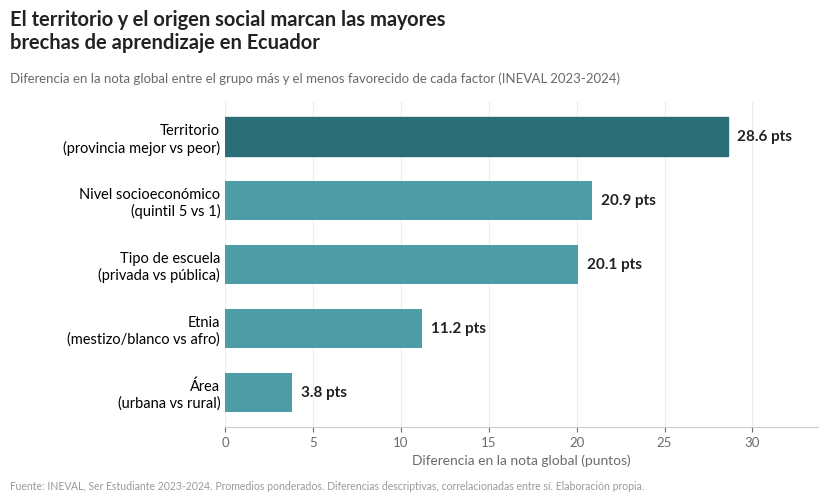

In [37]:
def brecha(grupo, alto, bajo):
    t = nota_por(ineval, grupo, "inev", "fex_inev")["nota"]
    return round(t.loc[alto] - t.loc[bajo], 1)

prov_t = nota_por(ineval, "prov_lbl", "inev", "fex_inev")["nota"]
gaps = {
    "Territorio\n(provincia mejor vs peor)": round(prov_t.max() - prov_t.min(), 1),
    "Nivel socioeconómico\n(quintil 5 vs 1)": brecha("quintil", 5.0, 1.0),
    "Tipo de escuela\n(privada vs pública)": brecha("fin_lbl", "Privado", "Publico"),
    "Etnia\n(mestizo/blanco vs afro)": brecha("etnia_lbl", "Mestizo/Blanco", "Afroecuatoriano"),
    "Área\n(urbana vs rural)": brecha("area_lbl", "Urbana", "Rural"),
}
# Se imprimen los valores que alimentan el grafico (todo sale de INEVAL, nada esta fijado a mano)
print("Brecha en la nota global (puntos), por factor:")
for k, v in sorted(gaps.items(), key=lambda kv: -kv[1]):
    print(f"  {k.splitlines()[0]:22s} {v:>5}")

items = sorted(gaps.items(), key=lambda kv: kv[1])   # ascendente: la brecha mayor queda arriba
labels, vals = [k for k, _ in items], [v for _, v in items]

fig, ax = plt.subplots(figsize=(8.6, 5.0))
bars = ax.barh(labels, vals, color=TEAL, height=0.62, zorder=3)
bars[-1].set_color(DARK)   # resaltar la brecha mayor
for b, v in zip(bars, vals):
    ax.text(v + 0.5, b.get_y() + b.get_height() / 2, f"{v:g} pts",
            va="center", ha="left", fontsize=11, fontweight="bold", color=INK)
ax.set_xlim(0, max(vals) * 1.18)
ax.set_xlabel("Diferencia en la nota global (puntos)", fontsize=10, color=GRAY)
estilo(ax); ax.tick_params(axis="y", length=0, labelsize=10.5)
ax.tick_params(axis="x", colors=GRAY, labelsize=9.5); ax.xaxis.grid(True, color="#ECECEC")
encabezado(fig, "El territorio y el origen social marcan las mayores\nbrechas de aprendizaje en Ecuador",
           "Diferencia en la nota global entre el grupo más y el menos favorecido de cada factor (INEVAL 2023-2024)",
           "Fuente: INEVAL, Ser Estudiante 2023-2024. Promedios ponderados. Diferencias descriptivas, correlacionadas entre sí. Elaboración propia.",
           left=0.27)
fig.savefig("figuras/01_brechas_factores.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

**Qué dice este gráfico.** Ordena los factores por el tamaño de la brecha en la nota global.
El territorio (28.6 puntos entre la mejor y la peor provincia) y el nivel socioeconómico de la
familia (20.9 puntos entre el quintil más rico y el más pobre) son las dos divisiones más grandes;
el tipo de escuela queda muy cerca. En cambio, el área urbano/rural por sí sola apenas separa
(3.9 puntos). Esto sostiene la primera parte de la tesis: en Ecuador, lo que más predice el
aprendizaje es de dónde viene el estudiante, no tanto si vive en ciudad o campo.

Dos advertencias para leerlo bien: las diferencias están **correlacionadas entre sí** (lo privado
y lo urbano concentran familias de mayor quintil), así que no son el efecto aislado de cada factor;
y son **descriptivas**, no causales.

## 2.2 R2 — Educación → Oportunidades

Con ENEMDU ya limpia: mediana del ingreso laboral por nivel educativo, ponderada por `fexp`.

In [38]:
r2 = (adultos.dropna(subset=["nivel_lbl", "fexp"])
             .groupby("nnivins")
             .apply(lambda d: pd.Series({
                 "nivel": d["nivel_lbl"].iloc[0],
                 "ingreso_mediana": round(wmedian(d["ingrl_val"], d["fexp"]), 0),
                 "n": len(d)}), include_groups=False))
print("ENEMDU 2023: ingreso laboral (mediana ponderada) por nivel educativo")
print(r2[["nivel", "ingreso_mediana", "n"]].to_string(index=False))

ENEMDU 2023: ingreso laboral (mediana ponderada) por nivel educativo
                       nivel  ingreso_mediana     n
                     Ninguno            140.0  2698
    Centro de Alfabetización             97.0   201
            Educacion Básica            280.0 47848
Educacion Media/Bachillerato            420.0 48603
                    Superior            650.0 42781


Lectura preliminar y límites: el ingreso sube con el nivel educativo. Mide el retorno del
**nivel** alcanzado (no de la calidad, que ENEMDU no observa); es transversal y no corrige el sesgo
de selección de quienes no trabajan.

## 2.3 R3 — Recursos → Resultados

A nivel país: ¿el aprendizaje (LAYS) se asocia con el gasto educativo y con el ratio
alumno-docente? Panel con el último dato disponible de cada indicador de OWID.

In [39]:
def owid_latest(fname, valcol, nuevo):
    d = pd.read_csv(DATA / "owid" / fname).rename(columns={valcol: nuevo}).dropna(subset=[nuevo])
    return d.sort_values("Year").groupby("Code").tail(1).set_index("Code")[nuevo]

panel = pd.concat([
    owid_latest("years-of-schooling.csv", "Both genders", "LAYS"),
    owid_latest("education-spending.csv", "Total across all levels of education", "gasto_pib"),
    owid_latest("pupil-teacher-ratio-for-primary-education-by-country.csv",
                "Pupil-qualified teacher ratio in primary education", "ratio_ad"),
], axis=1).dropna(subset=["LAYS"])

print("Panel pais (", panel.shape[0], "paises ). Correlaciones con LAYS:")
print(panel.corr(numeric_only=True)["LAYS"].round(2).to_string())
print("\nEcuador y comparadores:")
print(panel.reindex(["ECU", "CHL", "PER", "COL", "KOR", "FIN"]).round(2).to_string())

Panel pais ( 174 paises ). Correlaciones con LAYS:
LAYS         1.00
gasto_pib    0.13
ratio_ad    -0.56

Ecuador y comparadores:
       LAYS  gasto_pib  ratio_ad
Code                            
ECU    8.70       3.69     23.25
CHL    9.41       4.91     18.18
PER    8.63       4.36     21.38
COL    8.62       5.26     23.46
KOR   11.68       5.41     14.48
FIN   11.74       6.38       NaN


Lectura preliminar y límites: aparece la asociación esperada (más gasto y menos alumnos por
docente van con más aprendizaje), pero es a nivel país (ecológica), con pocos casos y sin controlar
por el ingreso del país. Sirve para ubicar a Ecuador, no para afirmar causalidad.

# Parte 3 — Visualizaciones para sustentar la tesis

Cada gráfico responde una pregunta concreta y se exporta a PNG (carpeta `figuras/`) en un estilo
sobrio y consistente. Reutilizan los datos ya limpios de las partes anteriores. Se define primero
el estilo común y una función de percentiles ponderados (necesaria para los boxplots).

Se vuelve a recordar el estilo común (ya definido en la Parte 0). El encabezado coloca título,
subtítulo y fuente de forma compacta para evitar espacios en blanco.

In [40]:
print("Estilo y funciones de figuras disponibles desde la Parte 0:", "encabezado" in dir())

Estilo y funciones de figuras disponibles desde la Parte 0: True


### Gráfico 2 — La desigualdad desplaza toda la distribución (boxplot, R1)

Pregunta: ¿la ventaja socioeconómica mueve solo el promedio o toda la distribución de notas?

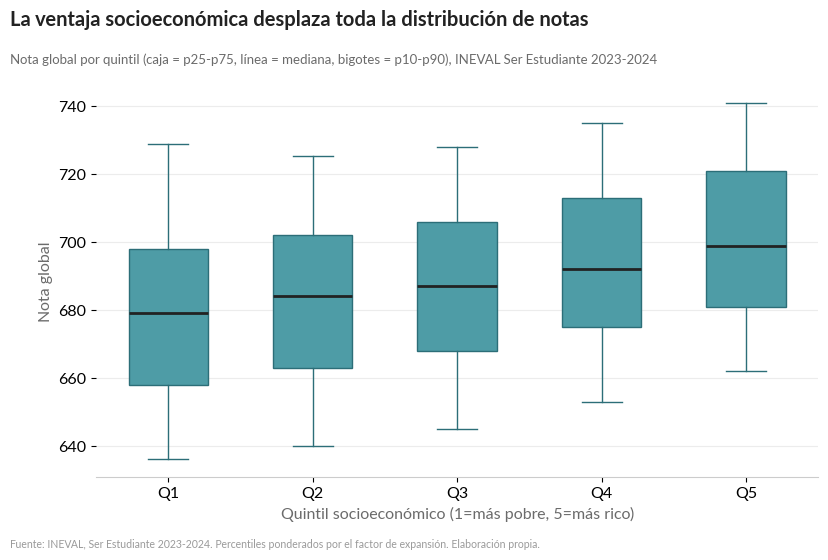

In [41]:
qd = ineval.dropna(subset=["quintil", "inev", "fex_inev"])
stats = []
for q in [1, 2, 3, 4, 5]:
    g = qd[qd["quintil"] == q]
    stats.append(dict(label=f"Q{q}", med=wq(g["inev"], g["fex_inev"], .5),
                      q1=wq(g["inev"], g["fex_inev"], .25), q3=wq(g["inev"], g["fex_inev"], .75),
                      whislo=wq(g["inev"], g["fex_inev"], .10), whishi=wq(g["inev"], g["fex_inev"], .90), fliers=[]))
fig, ax = plt.subplots(figsize=(8.6, 5.6))
ax.bxp(stats, patch_artist=True, widths=0.55, showfliers=False,
       boxprops=dict(facecolor=TEAL, edgecolor=DARK), medianprops=dict(color=INK, linewidth=2),
       whiskerprops=dict(color=DARK), capprops=dict(color=DARK))
ax.set_ylabel("Nota global", color=GRAY)
ax.set_xlabel("Quintil socioeconómico (1=más pobre, 5=más rico)", color=GRAY)
estilo(ax); ax.yaxis.grid(True, color="#ECECEC")
encabezado(fig,"La ventaja socioeconómica desplaza toda la distribución de notas",
           "Nota global por quintil (caja = p25-p75, línea = mediana, bigotes = p10-p90), INEVAL Ser Estudiante 2023-2024",
           "Fuente: INEVAL, Ser Estudiante 2023-2024. Percentiles ponderados por el factor de expansión. Elaboración propia.")
fig.savefig("figuras/02_boxplot_quintil.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

**Qué dice este gráfico.** No es solo que el promedio suba con el quintil: **toda la
distribución se desplaza**. La mediana pasa de ~679 (Q1) a ~699 (Q5), y las cajas (el 50% central)
casi no se solapan entre extremos. Es decir, un estudiante típico del quintil más alto rinde por
encima de buena parte de los del quintil más bajo. Un boxplot es el gráfico adecuado aquí porque
muestra la **dispersión**, no solo el centro, y deja ver que la desigualdad es estructural, no un
puñado de casos atípicos.

### Gráfico 3 — Ecuador frente a la región (dumbbell, comparación internacional)

¿En qué áreas Ecuador supera o no al promedio de los países de la región? Se usa ERCE porque es la
única fuente que aplica **la misma prueba** en 16 países, lo que hace la comparación válida.

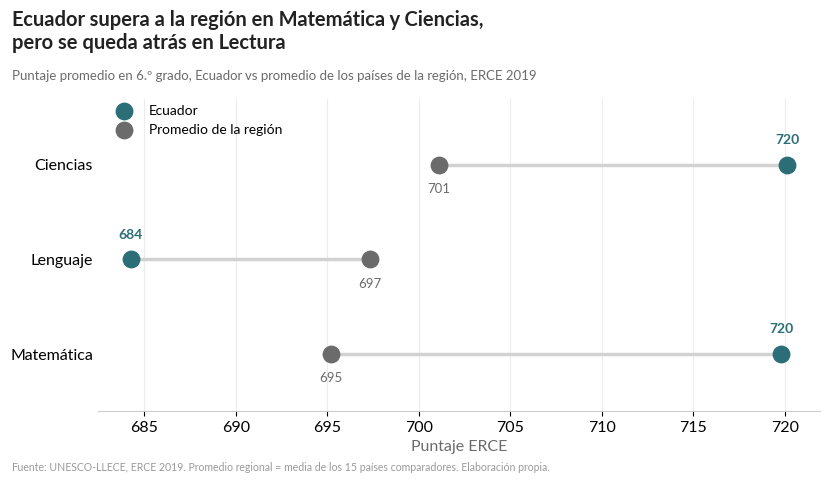

In [42]:
dom = ["MAT", "LAN", "SCI"]; nom = {"MAT": "Matemática", "LAN": "Lenguaje", "SCI": "Ciencias"}
pp = erce.groupby("COUNTRY").apply(lambda g: pd.Series({d: wmean(g[d], g["WT"]) for d in dom}), include_groups=False)
ecuv, regv = pp.loc["ECU"], pp.drop(index="ECU").mean()
fig, ax = plt.subplots(figsize=(8.6, 4.8))
for i, d in enumerate(dom):
    ax.plot([regv[d], ecuv[d]], [i, i], color="#d2d2d2", lw=2.5, zorder=1)
    ax.scatter(regv[d], i, s=140, color=GRAY, zorder=2)
    ax.scatter(ecuv[d], i, s=140, color=DARK, zorder=3)
    ax.text(ecuv[d], i + 0.22, f"{ecuv[d]:.0f}", ha="center", fontsize=10, color=DARK, fontweight="bold")
    ax.text(regv[d], i - 0.30, f"{regv[d]:.0f}", ha="center", fontsize=9.5, color=GRAY)
ax.set_yticks(range(len(dom))); ax.set_yticklabels([nom[d] for d in dom]); ax.set_ylim(-0.6, 2.7)
ax.scatter([], [], color=DARK, s=140, label="Ecuador"); ax.scatter([], [], color=GRAY, s=140, label="Promedio de la región")
ax.legend(loc="upper left", frameon=False, fontsize=10, bbox_to_anchor=(0, 1.02))
ax.set_xlabel("Puntaje ERCE", color=GRAY); estilo(ax); ax.xaxis.grid(True, color="#ECECEC"); ax.tick_params(axis="y", length=0)
encabezado(fig,"Ecuador supera a la región en Matemática y Ciencias,\npero se queda atrás en Lectura",
           "Puntaje promedio en 6.º grado, Ecuador vs promedio de los países de la región, ERCE 2019",
           "Fuente: UNESCO-LLECE, ERCE 2019. Promedio regional = media de los 15 países comparadores. Elaboración propia.")
fig.savefig("figuras/03_ecuador_vs_region.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

**Qué dice este gráfico.** Ecuador queda por encima del promedio regional en Matemática
(720 vs 695) y Ciencias (720 vs 701), pero **por debajo en Lenguaje** (684 vs 697). La debilidad
relativa del país está en lectura. Es un hallazgo que **coincide** con lo visto en INEVAL (la
desigualdad pegaba más fuerte en Lengua): dos fuentes distintas, años distintos, apuntando a lo
mismo. No es una medición única, sino una convergencia de indicios.

### Gráfico 4 — Ranking regional en Matemática (barras, comparación internacional)

¿En qué lugar de la región se ubica Ecuador? El ranking ordena los 16 países por su puntaje medio
en Matemática y resalta a Ecuador.

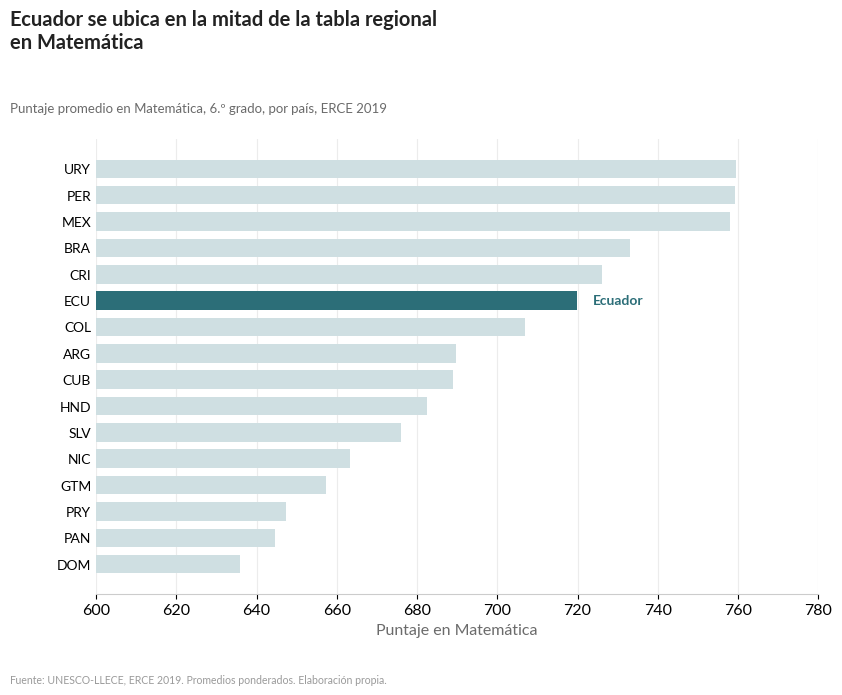

In [43]:
mat = erce.groupby("COUNTRY").apply(lambda g: wmean(g["MAT"], g["WT"]), include_groups=False).sort_values()
fig, ax = plt.subplots(figsize=(8.6, 7))
colors = [DARK if c == "ECU" else "#cfdfe2" for c in mat.index]
ax.barh(mat.index, mat.values, color=colors, height=0.7)
ax.text(mat["ECU"] + 4, list(mat.index).index("ECU"), "Ecuador", va="center", color=DARK, fontweight="bold", fontsize=10)
ax.set_xlabel("Puntaje en Matemática", color=GRAY); ax.set_xlim(600, 780)
estilo(ax); ax.xaxis.grid(True, color="#ECECEC"); ax.tick_params(axis="y", length=0, labelsize=10)
encabezado(fig,"Ecuador se ubica en la mitad de la tabla regional\nen Matemática",
           "Puntaje promedio en Matemática, 6.º grado, por país, ERCE 2019",
           "Fuente: UNESCO-LLECE, ERCE 2019. Promedios ponderados. Elaboración propia.")
fig.savefig("figuras/04_ranking_paises.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

**Qué dice este gráfico.** Ecuador se ubica a media tabla regional en Matemática: por encima de
países como Guatemala, Panamá o República Dominicana, pero por debajo de Perú, Uruguay, México o
Costa Rica. No es ni el mejor ni el peor de la región; está en una posición intermedia que deja
margen claro de mejora respecto a los líderes.

### Gráfico 5 — Ingreso por nivel educativo (boxplot, R2)

¿Cómo se relaciona el nivel educativo alcanzado con el ingreso laboral? Se usa ENEMDU porque es la
encuesta oficial que mide ingreso y educación a nivel de persona; se usa la **mediana** (no la
media) por la fuerte asimetría de los ingresos.

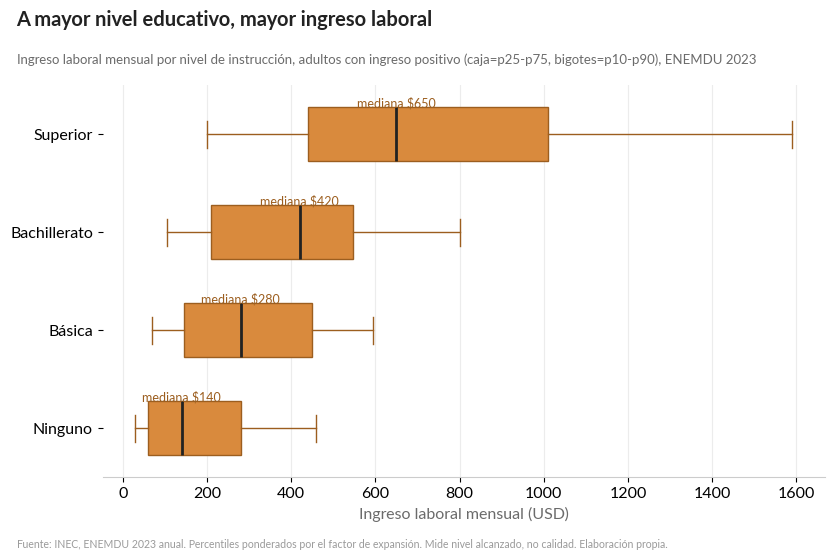

In [44]:
orden = [1, 3, 4, 5]   # se omite Centro de Alfabetizacion (n pequeno)
nombres = {1: "Ninguno", 3: "Básica", 4: "Bachillerato", 5: "Superior"}
st = []
for nv in orden:
    g = adultos[adultos["nnivins"] == nv]
    st.append(dict(label=nombres[nv], med=wq(g["ingrl_val"], g["fexp"], .5),
                   q1=wq(g["ingrl_val"], g["fexp"], .25), q3=wq(g["ingrl_val"], g["fexp"], .75),
                   whislo=wq(g["ingrl_val"], g["fexp"], .10), whishi=wq(g["ingrl_val"], g["fexp"], .90), fliers=[]))
fig, ax = plt.subplots(figsize=(8.6, 5.6))
ax.bxp(st, vert=False, patch_artist=True, widths=0.55, showfliers=False,
       boxprops=dict(facecolor=ORANGE, edgecolor="#9c5e1f"), medianprops=dict(color=INK, linewidth=2),
       whiskerprops=dict(color="#9c5e1f"), capprops=dict(color="#9c5e1f"))
for i, s in enumerate(st):
    ax.text(s["med"], i + 1.28, f"mediana ${s['med']:.0f}", ha="center", fontsize=9, color="#9c5e1f")
ax.set_xlabel("Ingreso laboral mensual (USD)", color=GRAY); estilo(ax); ax.xaxis.grid(True, color="#ECECEC")
encabezado(fig,"A mayor nivel educativo, mayor ingreso laboral",
           "Ingreso laboral mensual por nivel de instrucción, adultos con ingreso positivo (caja=p25-p75, bigotes=p10-p90), ENEMDU 2023",
           "Fuente: INEC, ENEMDU 2023 anual. Percentiles ponderados por el factor de expansión. Mide nivel alcanzado, no calidad. Elaboración propia.")
fig.savefig("figuras/05_boxplot_ingreso.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

**Qué dice este gráfico.** El ingreso laboral crece con cada nivel educativo: la mediana pasa
de ~$140 (sin estudios) a ~$280 (básica), ~$420 (bachillerato) y ~$650 (superior). La caja de
"Superior" además se estira mucho hacia la derecha (mayor techo de ingresos). Esto conecta la
educación con las **oportunidades** (R2). Importante: ENEMDU mide el **nivel** educativo alcanzado,
no la calidad del aprendizaje, así que esto habla del retorno de completar más años/niveles, no de
aprender mejor; y como es transversal, no corrige que quienes no trabajan no aparecen.

### Gráfico 6 — Recursos y resultados (scatter, R3)

A nivel país, ¿el aprendizaje se asocia con la cantidad de alumnos por docente? Se usa OWID porque
ofrece el indicador LAYS (aprendizaje comparable) y la ratio alumno-docente para casi 130 países.

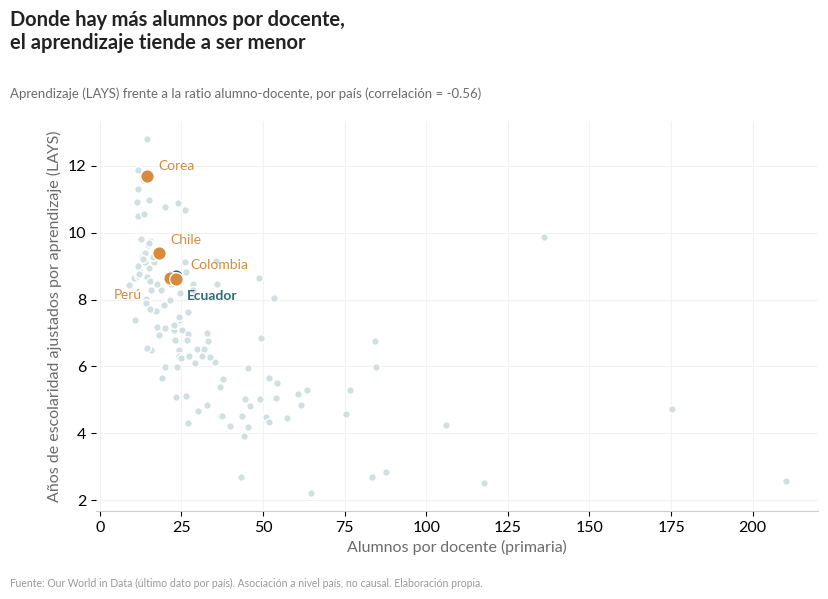

In [45]:
sc = panel.dropna(subset=["LAYS", "ratio_ad"])
fig, ax = plt.subplots(figsize=(8.6, 6))
ax.scatter(sc["ratio_ad"], sc["LAYS"], s=30, color="#cfdfe2", edgecolor="white", zorder=2)
foco = {"ECU": ("Ecuador", (8, -17), DARK, "bold"), "PER": ("Perú", (-40, -15), ORANGE, "normal"),
        "COL": ("Colombia", (10, 7), ORANGE, "normal"), "CHL": ("Chile", (8, 6), ORANGE, "normal"),
        "KOR": ("Corea", (8, 5), ORANGE, "normal"), "FIN": ("Finlandia", (6, -16), ORANGE, "normal")}
for c, (lab, off, col, fw) in foco.items():
    if c in sc.index:
        ax.scatter(sc.loc[c, "ratio_ad"], sc.loc[c, "LAYS"], s=95, color=col, zorder=3, edgecolor="white")
        ax.annotate(lab, (sc.loc[c, "ratio_ad"], sc.loc[c, "LAYS"]), xytext=off, textcoords="offset points",
                    fontsize=10, fontweight=fw, color=col)
ax.set_xlabel("Alumnos por docente (primaria)", color=GRAY)
ax.set_ylabel("Años de escolaridad ajustados por aprendizaje (LAYS)", color=GRAY)
estilo(ax); ax.grid(True, color="#F2F2F2")
r = sc["LAYS"].corr(sc["ratio_ad"])
encabezado(fig,"Donde hay más alumnos por docente,\nel aprendizaje tiende a ser menor",
           f"Aprendizaje (LAYS) frente a la ratio alumno-docente, por país (correlación = {r:.2f})",
           "Fuente: Our World in Data (último dato por país). Asociación a nivel país, no causal. Elaboración propia.")
fig.savefig("figuras/06_scatter_recursos.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

**Qué dice este gráfico.** Hay una asociación negativa moderada (correlación −0.56): los países
con más alumnos por docente tienden a aprender menos. Ecuador (≈23 alumnos por docente) se ubica en
el grupo intermedio, lejos del rincón superior izquierdo donde están Corea y Finlandia (pocos
alumnos por docente y alto aprendizaje). Es una relación **ecológica** (a nivel país, no de
estudiante), con pocos casos y sin controlar por el ingreso del país, así que describe dónde está
Ecuador, no demuestra que reducir el tamaño de la clase cause más aprendizaje.

### Gráfico 7 — Inversión educativa en el tiempo (línea, R3)

¿Cómo ha evolucionado el gasto público en educación de Ecuador? Un gráfico de líneas es el adecuado
para ver evolución temporal.

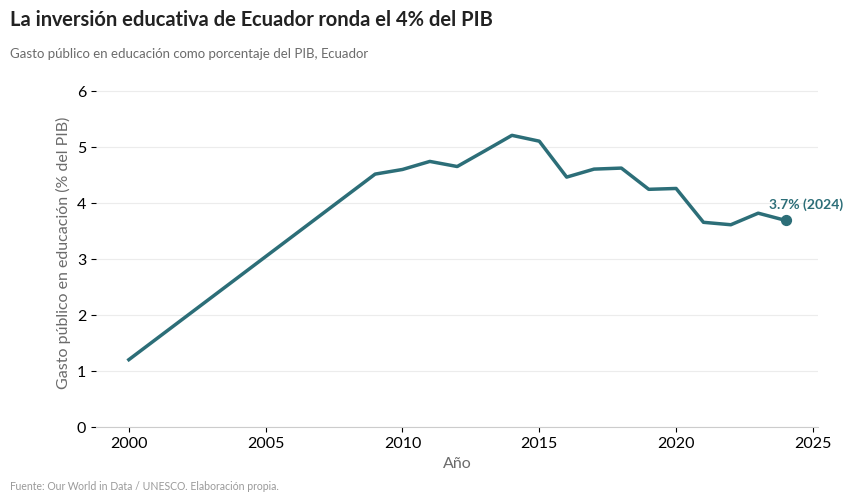

In [46]:
gs = pd.read_csv(DATA / "owid" / "education-spending.csv").rename(columns={"Total across all levels of education": "gasto"})
ge = gs[gs["Code"] == "ECU"].dropna(subset=["gasto"]).sort_values("Year")
ge = ge[ge["Year"] >= 2000]
fig, ax = plt.subplots(figsize=(8.6, 5))
ax.plot(ge["Year"], ge["gasto"], color=DARK, lw=2.5, zorder=3)
ax.scatter(ge["Year"].iloc[[-1]], ge["gasto"].iloc[[-1]], color=DARK, s=50, zorder=4)
ax.annotate(f"{ge['gasto'].iloc[-1]:.1f}% ({int(ge['Year'].iloc[-1])})",
            (ge["Year"].iloc[-1], ge["gasto"].iloc[-1]), xytext=(-12, 9), textcoords="offset points",
            fontsize=10, color=DARK, fontweight="bold")
ax.set_ylabel("Gasto público en educación (% del PIB)", color=GRAY); ax.set_xlabel("Año", color=GRAY)
ax.set_ylim(0, ge["gasto"].max() * 1.2); estilo(ax); ax.yaxis.grid(True, color="#ECECEC")
encabezado(fig,"La inversión educativa de Ecuador ronda el 4% del PIB",
           "Gasto público en educación como porcentaje del PIB, Ecuador",
           "Fuente: Our World in Data / UNESCO. Elaboración propia.")
fig.savefig("figuras/07_linea_gasto.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

**Qué dice este gráfico.** Tras crecer fuerte en los 2000, la inversión educativa de Ecuador
alcanzó un pico cercano al 5% del PIB hacia 2014-2015 y desde entonces ha descendido hasta rondar
el 3.7% en el dato más reciente. El contexto importa para R3: Ecuador no solo invierte menos que el
país líder de la región, sino que su esfuerzo relativo ha venido **cayendo** en los últimos años.

### Gráfico 8 — Ecuador frente al país mejor educado de la región (gráfico central)

Este es el gráfico que responde de forma más directa la pregunta de investigación. Primero se
**determina con datos** cuál es el país de mejor desempeño educativo de América Latina (el de mayor
LAYS), y luego se comparan los factores estructurales de Ecuador frente a ese país.

In [47]:
lays_all = (pd.read_csv(DATA / "owid" / "years-of-schooling.csv")
              .rename(columns={"Both genders": "LAYS"}).dropna(subset=["LAYS"]))
lays_all = lays_all.sort_values("Year").groupby("Code").tail(1)
latam = ["ARG", "BOL", "BRA", "CHL", "COL", "CRI", "CUB", "DOM", "ECU", "SLV", "GTM",
         "HND", "MEX", "NIC", "PAN", "PRY", "PER", "URY", "VEN"]
lays_latam = (lays_all[lays_all["Code"].isin(latam)]
              .set_index("Code")["LAYS"].sort_values(ascending=False))
mejor = lays_latam.index[0]
print("Aprendizaje (LAYS) en America Latina, ranking (top 6):")
print(lays_latam.round(2).head(6).to_string())
print("\nPais mejor educado de la region:", mejor, "( LAYS =", round(lays_latam.iloc[0], 2), ")")

Aprendizaje (LAYS) en America Latina, ranking (top 6):
Code
CHL    9.41
CRI    8.99
MEX    8.82
ECU    8.70
PER    8.63
COL    8.62

Pais mejor educado de la region: CHL ( LAYS = 9.41 )


Factores estructurales: Ecuador vs Chile (valores que alimentan el grafico)
  Aprendizaje (LAYS, años)         ECU=    8.7   CHL=    9.4
  Gasto educativo (% PIB)          ECU=    3.7   CHL=    4.9
  Acceso a internet (% pob.)       ECU=   72.7   CHL=   94.5
  Matrícula terciaria (% bruta)    ECU=   67.9   CHL=  104.7
  Finaliz. secundaria alta (%)     ECU=   80.8   CHL=   92.7
  Alumnos por docente              ECU=   23.3   CHL=   18.2


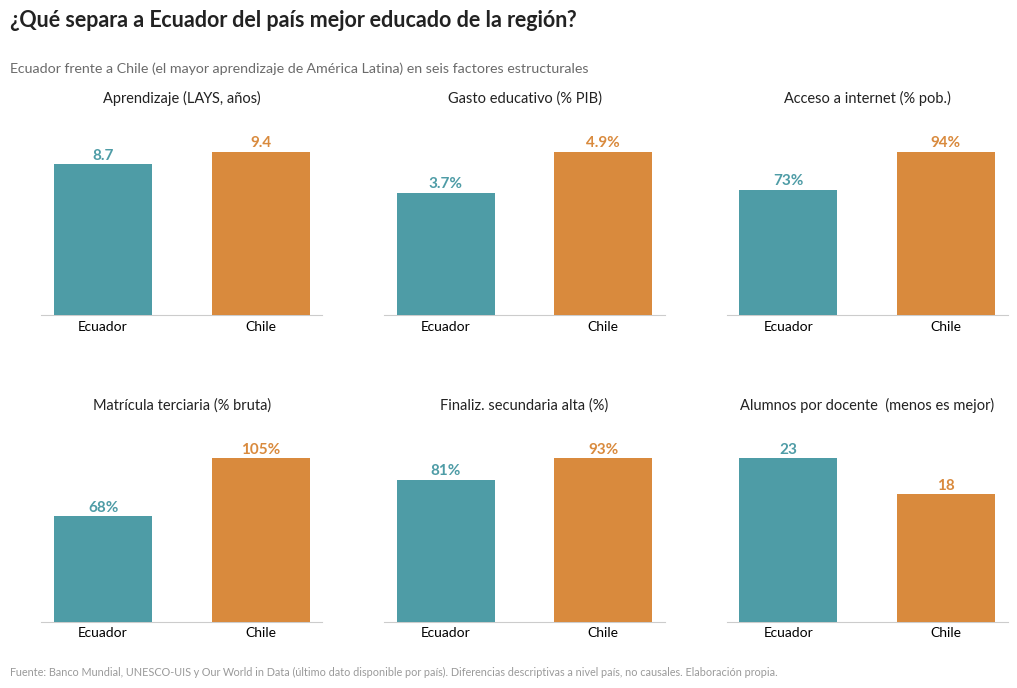

In [48]:
def wb_last(ind, code):
    d = wb_get(ind, code).dropna(subset=["valor"])
    return d.sort_values("anio")["valor"].iloc[-1] if len(d) else np.nan

def uis_last(ind, code):
    d = uis_get(ind, code).dropna(subset=["value"])
    return d.sort_values("year")["value"].iloc[-1] if len(d) else np.nan

# Seis factores estructurales comparables (Ecuador vs el mejor pais)
F = [
    ("Aprendizaje (LAYS, años)",      panel.loc["ECU", "LAYS"],      panel.loc[mejor, "LAYS"],      "{:.1f}",  False),
    ("Gasto educativo (% PIB)",       panel.loc["ECU", "gasto_pib"], panel.loc[mejor, "gasto_pib"], "{:.1f}%", False),
    ("Acceso a internet (% pob.)",    wb_last("IT.NET.USER.ZS", "ECU"), wb_last("IT.NET.USER.ZS", mejor), "{:.0f}%", False),
    ("Matrícula terciaria (% bruta)", wb_last("SE.TER.ENRR", "ECU"),    wb_last("SE.TER.ENRR", mejor),    "{:.0f}%", False),
    ("Finaliz. secundaria alta (%)",  uis_last("CR.3", "ECU"),          uis_last("CR.3", mejor),          "{:.0f}%", False),
    ("Alumnos por docente",           panel.loc["ECU", "ratio_ad"],  panel.loc[mejor, "ratio_ad"],  "{:.0f}",  True),
]
nombre = {"CHL": "Chile", "CRI": "Costa Rica", "URY": "Uruguay", "MEX": "México", "PER": "Perú"}.get(mejor, mejor)

print(f"Factores estructurales: Ecuador vs {nombre} (valores que alimentan el grafico)")
for nom, e, c, fmt, low in F:
    print(f"  {nom:32s} ECU={e:7.1f}   {mejor}={c:7.1f}")

fig, axes = plt.subplots(2, 3, figsize=(10.5, 7))
for ax, (nom, e, c, fmt, low) in zip(axes.flat, F):
    ax.bar([0, 1], [e, c], color=[TEAL, ORANGE], width=0.62, zorder=3)
    for x, v in zip([0, 1], [e, c]):
        ax.text(x, v + max(e, c) * 0.03, fmt.format(v), ha="center", fontsize=11,
                fontweight="bold", color=TEAL if x == 0 else ORANGE)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Ecuador", nombre], fontsize=10)
    ax.set_ylim(0, max(e, c) * 1.25)
    ax.set_title(nom + ("  (menos es mejor)" if low else ""), fontsize=10.5, color=INK, pad=6)
    for s in ["top", "right", "left"]:
        ax.spines[s].set_visible(False)
    ax.spines["bottom"].set_color("#ccc"); ax.set_yticks([]); ax.tick_params(axis="x", length=0)
fig.subplots_adjust(top=0.83, bottom=0.10, hspace=0.5, wspace=0.22, left=0.05, right=0.97)
fig.text(0.02, 0.975, "¿Qué separa a Ecuador del país mejor educado de la región?",
         va="top", ha="left", fontsize=15.5, fontweight="bold", color=INK)
fig.text(0.02, 0.90, f"Ecuador frente a {nombre} (el mayor aprendizaje de América Latina) en seis "
         "factores estructurales", va="top", ha="left", fontsize=10.3, color=GRAY)
fig.text(0.02, 0.02,
         "Fuente: Banco Mundial, UNESCO-UIS y Our World in Data (último dato disponible por país). "
         "Diferencias descriptivas a nivel país, no causales. Elaboración propia.",
         va="bottom", ha="left", fontsize=7.8, color="#9a9a9a")
fig.savefig("figuras/08_ecuador_vs_mejor.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

**Qué dice este gráfico (y cómo se llegó a él).** Primero el código **calcula** qué país de
América Latina tiene el mayor aprendizaje (LAYS): el resultado es Chile. Luego compara seis factores
estructurales. Ecuador queda por detrás en todos los que conviene tener altos —aprendizaje (8.7 vs
9.4), gasto educativo (3.8% vs 4.9% del PIB), acceso a internet (73% vs 94%), matrícula terciaria
(68% vs 105%) y finalización del bachillerato (81% vs 93%)— y tiene más alumnos por docente
(23 vs 18). Es la respuesta más directa a la pregunta de investigación: las diferencias con el país
líder de la región no son solo de resultados, sino de **condiciones estructurales**. Sigue siendo
una comparación descriptiva a nivel país, no causal.

# Parte 4 — Síntesis y conclusión

**Lo que muestran los datos.** Recorriendo las tres relaciones, el panorama es consistente:

- *Origen y calidad (R1).* Dentro de Ecuador, el aprendizaje está fuertemente estratificado por
  nivel socioeconómico, territorio, tipo de escuela y etnia. La brecha entre el quintil más rico y
  el más pobre es del orden de dos años de escolaridad, y toda la distribución de notas —no solo el
  promedio— se desplaza con el nivel socioeconómico.
- *Comparación internacional.* Con la misma prueba regional (ERCE), Ecuador rinde a media tabla, con
  una debilidad clara en lectura. Frente al país de mejor desempeño (Chile), queda por detrás en
  cada factor estructural medido.
- *Educación y oportunidades (R2).* El nivel educativo se asocia con un ingreso laboral
  marcadamente mayor, lo que conecta las brechas educativas con desigualdades futuras.
- *Recursos y resultados (R3).* A nivel país, más alumnos por docente y menos inversión se asocian
  con menor aprendizaje; Ecuador combina inversión decreciente y resultados intermedios.

**Conclusión.** La evidencia respalda la narrativa de partida: Ecuador no solo tiene menor
desempeño educativo que los países líderes de la región, sino también mayores desigualdades
estructurales internas (socioeconómicas y territoriales). Estas diferencias se asocian con menores
oportunidades —ingreso, acceso a la educación superior—, aunque con los datos disponibles esto se
plantea como patrón, no como relación causal demostrada.

**Por qué cada fuente.** INEVAL aporta el detalle interno por estudiante; ERCE permite la única
comparación internacional válida (misma prueba); ENEMDU conecta educación con ingreso; Banco
Mundial, UNESCO-UIS y OWID dan los factores estructurales comparables entre países. SEDLAC y las
Cuentas Satélite quedaron como contexto; PISA/TIMSS/PIRLS y OECD se descartaron porque Ecuador no
participa, y Censo/ECV por estar fuera del alcance o desfasados.

**Límites a tener presentes.** Todo es descriptivo y correlacional: los diseños son transversales,
los cortes están correlacionados entre sí, no se sigue a las personas en el tiempo y no se puede
vincular la nota individual con el salario futuro. Las comparaciones entre fuentes respetan que
cada una corresponde a años y universos distintos.